In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip3 install ipython-autotime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.2 MB/s eta 0:00:00


In [3]:
%load_ext autotime
import pandas as pd
import numpy as np
# import pickle5 as pickle
import re
from tqdm.notebook import tqdm
tqdm.pandas()
import os
import re
import pickle as pkl

time: 392 ms (started: 2023-03-11 00:33:55 +00:00)


In [4]:
dataset_path = '/content/drive/MyDrive/Kialo/serializedGraphs/'
files = os.listdir(dataset_path)
len(files)

1560

time: 13.5 s (started: 2023-03-11 00:34:24 +00:00)


In [ ]:
# !unzip "/content/drive/MyDrive/Kialo/kialo_debates.zip" -d "/content/drive/MyDrive/Kialo/"

In [ ]:
dataset_path = '/content/drive/MyDrive/Kialo/serializedGraphs/'
files = os.listdir(dataset_path)
dataset_samples = []
labels = []
text_df=pd.DataFrame()

for file_x in tqdm(files):
    data = pkl.load(open(dataset_path + file_x, 'rb'))
    print(f'{file_x} >>> ',end='')
    for node_id_x in data.node:
      node_x = data.node[node_id_x].copy()
      if node_id_x.split('.')[1] != '0':
        parent_node_id_x = list(data.edge[node_id_x].keys())[0]
        weight_x = data.edge[node_id_x][parent_node_id_x]['weight']
      else:
        parent_node_id_x = ''
        weight_x = 0
      node_x.update({'file': file_x, 'node_id': node_id_x, 'parent_node_id':parent_node_id_x, 'weight':weight_x})
      text_df = text_df.append(node_x,ignore_index=True)

import datetime
text_df['created'] = text_df['created'].apply(lambda x: datetime.datetime.utcfromtimestamp(x/1000).strftime('%Y-%m-%d %H:%M:%S'))

  0%|          | 0/1560 [00:00<?, ?it/s]

24631.pkl >>> 31941.pkl >>> 18740.pkl >>> 23902.pkl >>> 10343.pkl >>> 2469.pkl >>> 23340.pkl >>> 23831.pkl >>> 31832.pkl >>> 10341.pkl >>> 29929.pkl >>> 16026.pkl >>> 17763.pkl >>> 2408.pkl >>> 16218.pkl >>> 29923.pkl >>> 2710.pkl >>> 17822.pkl >>> 27032.pkl >>> 14447.pkl >>> 12278.pkl >>> 30362.pkl >>> 17768.pkl >>> 32290.pkl >>> 31828.pkl >>> 32864.pkl >>> 17976.pkl >>> 15489.pkl >>> 5496.pkl >>> 15628.pkl >>> 16962.pkl >>> 26453.pkl >>> 16755.pkl >>> 16598.pkl >>> 16201.pkl >>> 23728.pkl >>> 24439.pkl >>> 7768.pkl >>> 1955.pkl >>> 14232.pkl >>> 1922.pkl >>> 7776.pkl >>> 7487.pkl >>> 921.pkl >>> 29497.pkl >>> 26461.pkl >>> 15491.pkl >>> 9576.pkl >>> 14940.pkl >>> 16680.pkl >>> 16566.pkl >>> 18191.pkl >>> 13876.pkl >>> 4401.pkl >>> 6086.pkl >>> 23139.pkl >>> 28280.pkl >>> 15121.pkl >>> 16974.pkl >>> 19648.pkl >>> 12788.pkl >>> 15943.pkl >>> 31028.pkl >>> 29944.pkl >>> 27936.pkl >>> 30959.pkl >>> 25506.pkl >>> 13225.pkl >>> 5909.pkl >>> 1108.pkl >>> 26678.pkl >>> 7572.pkl >>> 23298.pkl

In [ ]:
text_df

,edited,votes,created,text,author,relation,file,node_id,parent_node_id,weight
0,1.544792e+12,"[0, 0, 0, 0, 0]",2018-12-14 12:47:47,Retention elections don't especially politiciz...,0dd5353c-3947-4069-9e12-c051be197740,1.0,24631.pkl,24631.50,24631.10,1.0
1,1.544792e+12,"[0, 0, 0, 0, 0]",2018-12-14 12:45:00,Supreme Court Justices already hold largely to...,0dd5353c-3947-4069-9e12-c051be197740,1.0,24631.pkl,24631.40,24631.10,1.0
2,1.544792e+12,"[0, 0, 0, 0, 0]",2018-12-14 12:48:40,It's unlikely this sort of constitutional amen...,0dd5353c-3947-4069-9e12-c051be197740,-1.0,24631.pkl,24631.70,24631.10,-1.0
3,1.544792e+12,"[0, 0, 0, 0, 0]",2018-12-14 12:48:10,This would be a massive constitutional shift.,0dd5353c-3947-4069-9e12-c051be197740,-1.0,24631.pkl,24631.60,24631.10,-1.0
4,1.544791e+12,"[0, 0, 0, 0, 0]",2018-12-14 12:42:25,Americans should be able to vote on whether or...,0dd5353c-3947-4069-9e12-c051be197740,0.0,24631.pkl,24631.10,24631.00,0.0
...,...,...,...,...,...,...,...,...,...,...
329008,1.569865e+12,"[0, 0, 0, 0, 0]",2019-09-30 17:42:14,This is an appropriate consequence for their f...,0af77b22-4423-4481-bb50-a0a70d7c57c4,-1.0,30562.pkl,30562.98,30562.74,-1.0
329009,1.569865e+12,"[0, 0, 0, 0, 0]",2019-09-30 17:41:46,Shutting down the internet does not mean destr...,0af77b22-4423-4481-bb50-a0a70d7c57c4,-1.0,30562.pkl,30562.96,30562.74,-1.0
329010,1.569678e+12,"[0, 0, 0, 0, 0]",2019-09-28 13:36:28,People can find about this through [whistleblo...,bcd8245e-38da-4079-840e-695f01d30806,1.0,30562.pkl,30562.90,30562.88,1.0
329011,1.569678e+12,"[0, 0, 0, 0, 0]",2019-09-28 13:37:24,Governments can easily deny this since the inf...,bcd8245e-38da-4079-840e-695f01d30806,-1.0,30562.pkl,30562.92,30562.90,-1.0


time: 40.8 ms (started: 2023-03-02 16:10:38 +00:00)


In [ ]:
text_df.to_csv('/content/drive/MyDrive/Kialo/all_text.csv', index=False)

time: 8.89 s (started: 2023-03-02 14:51:06 +00:00)


In [ ]:
text_df=pd.read_csv('/content/drive/MyDrive/Kialo/all_text.csv')

time: 3.94 s (started: 2023-03-03 11:29:20 +00:00)


In [ ]:
text_df.sort_values(by='created')

,edited,votes,created,text,author,relation,file,node_id,parent_node_id,weight
101487,1.380182e+12,"[0, 0, 0, 0, 0]",2013-09-26 07:48:38,"Legalize all drugs, including hard drugs like ...",0077c272-1fdc-4202-a06a-160482dfc12d,0.0,2027.pkl,2027.1000,2027.000,0.0
101194,1.432740e+12,"[0, 0, 0, 0, 0]",2013-09-26 07:48:38,What is the best drug regulation system?,0077c272-1fdc-4202-a06a-160482dfc12d,0.0,2027.pkl,2027.0000,NaN,0.0
101188,1.380182e+12,"[0, 0, 0, 0, 0]",2013-09-26 07:52:03,Legalizing drugs and taxing their sale would p...,0077c272-1fdc-4202-a06a-160482dfc12d,1.0,2027.pkl,2027.2000,2027.100,1.0
101718,1.380182e+12,"[0, 0, 0, 0, 0]",2013-09-26 07:52:20,This would likely only be the case if the stat...,0077c272-1fdc-4202-a06a-160482dfc12d,-1.0,2027.pkl,2027.3000,2027.200,-1.0
101177,1.380182e+12,"[0, 0, 0, 0, 2]",2013-09-26 07:53:07,Alcohol and nicotine are regulated and the gov...,0077c272-1fdc-4202-a06a-160482dfc12d,-1.0,2027.pkl,2027.4000,2027.300,-1.0
...,...,...,...,...,...,...,...,...,...,...
291266,1.580203e+12,"[0, 0, 0, 0, 0]",2020-01-28 09:09:28,If a reader has to independently verify if the...,3ad5977b-b81c-46c9-8c91-6deafe6dfe55,-1.0,33056.pkl,33056.1010,33056.190,-1.0
291267,1.580203e+12,"[0, 0, 0, 0, 0]",2020-01-28 09:12:05,Corrections are usually extremely small and hi...,3ad5977b-b81c-46c9-8c91-6deafe6dfe55,-1.0,33056.pkl,33056.1030,33056.580,-1.0
291264,1.580203e+12,"[0, 0, 0, 0, 0]",2020-01-28 09:13:03,"Whether the mistakes are honest or not, if the...",3ad5977b-b81c-46c9-8c91-6deafe6dfe55,-1.0,33056.pkl,33056.1050,33056.110,-1.0
84217,1.580206e+12,"[0, 0, 0, 0, 0]",2020-01-28 10:11:33,Humans can live long and healthy lives without...,25583b1c-a25a-4a8f-aa94-f76d4e567066,-1.0,7721.pkl,7721.1806,7721.880,-1.0


time: 134 ms (started: 2023-03-03 11:59:45 +00:00)


In [ ]:
text_df["created"] = text_df["created"].astype("datetime64")

time: 86.4 ms (started: 2023-03-03 11:59:42 +00:00)


<AxesSubplot:xlabel='created'>

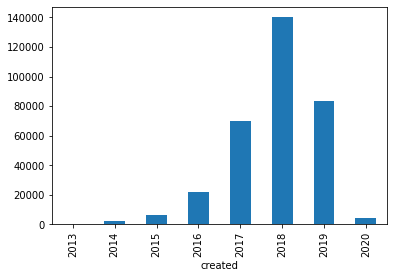

time: 607 ms (started: 2023-03-03 12:00:50 +00:00)


In [ ]:
text_df.groupby(text_df["created"].dt.year)['node_id'].count().plot(kind="bar")

In [ ]:
def parent_finder(node_x):
  node_x_str = list(str(node_x).split('.'))
  if len(node_x_str)<2:
    return False
  else:
    return node_x_str[1]=='0'

time: 1.65 ms (started: 2023-03-02 15:38:35 +00:00)


In [ ]:
text_df_=text_df[text_df['parent_node_id'].apply(lambda x: parent_finder(x))]

time: 1.87 s (started: 2023-03-02 15:51:52 +00:00)


In [ ]:
text_df_[text_df_['parent_node_id'].duplicated()]

,edited,votes,created,text,author,relation,file,node_id,parent_node_id,weight
3585,1.570355e+12,"[0, 0, 0, 0, 0]",2019-10-06 09:37:24,Put a \(fake\) camera and a camera sign to pre...,9cd4af83-29a3-4320-b180-cf65f89c4db7,0.0,29923.pkl,29923.62,29923.0,0.0
3589,1.562834e+12,"[0, 0, 0, 0, 0]",2019-07-11 08:31:36,Put up more signs as reminders! Think about pu...,770337a3-a506-4537-9e8f-f4db3553d16b,0.0,29923.pkl,29923.12,29923.0,0.0
3591,1.562833e+12,"[0, 0, 0, 0, 1]",2019-07-11 08:23:05,Closing the loop at the entrance with a barrie...,770337a3-a506-4537-9e8f-f4db3553d16b,0.0,29923.pkl,29923.10,29923.0,0.0
3598,1.562832e+12,"[0, 0, 0, 0, 0]",2019-07-11 07:54:29,"Take away our loop from the map, by changing t...",770337a3-a506-4537-9e8f-f4db3553d16b,0.0,29923.pkl,29923.80,29923.0,0.0
3599,1.562832e+12,"[0, 0, 0, 0, 0]",2019-07-11 08:04:07,Develop a sort of natural design which discour...,770337a3-a506-4537-9e8f-f4db3553d16b,0.0,29923.pkl,29923.90,29923.0,0.0
...,...,...,...,...,...,...,...,...,...,...
326261,1.563718e+12,"[3, 1, 0, 0, 0]",2019-07-21 14:12:04,Thinking about another than your partner sexua...,df0d1ddd-e3d3-47d2-ba4d-e854b9c01b01,0.0,30015.pkl,30015.10,30015.0,0.0
326262,1.563718e+12,"[2, 0, 1, 0, 1]",2019-07-21 14:12:17,Masturbation is an act of unfaithfulness.,df0d1ddd-e3d3-47d2-ba4d-e854b9c01b01,0.0,30015.pkl,30015.20,30015.0,0.0
326263,1.563718e+12,"[0, 1, 1, 0, 0]",2019-07-21 14:12:42,Going out on a date with anyone but your signi...,df0d1ddd-e3d3-47d2-ba4d-e854b9c01b01,0.0,30015.pkl,30015.30,30015.0,0.0
326264,1.563719e+12,"[1, 0, 0, 0, 3]",2019-07-21 14:15:40,"Sexual acts that do not involve penetration, s...",df0d1ddd-e3d3-47d2-ba4d-e854b9c01b01,0.0,30015.pkl,30015.80,30015.0,0.0


time: 44.6 ms (started: 2023-03-02 16:37:51 +00:00)


In [ ]:
text_df[text_df['node_id']==29923.0]['text']#[326260]

3600    Take back our boardwalk \@Droef
Name: text, dtype: object

time: 15.3 ms (started: 2023-03-02 16:42:00 +00:00)


In [ ]:
node_x_str = list(str(node_x).split('.'))
if len(node_x_str)<2:
  print('False')
else:
  print(node_x_str[1]==0)

False
time: 2.5 ms (started: 2023-03-02 15:38:14 +00:00)


In [ ]:
len(files)

1560

time: 3.31 ms (started: 2023-03-02 15:50:54 +00:00)
